In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from sklearn.metrics.pairwise import linear_kernel
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

In [13]:
# Load the dataset
zomato_raw = pd.read_csv("zomato.csv")

# Checking dataset size
print(zomato_raw.shape)

# Checking the columns in the dataset
print(zomato_raw.columns)

# Display first two rows
zomato_raw.head(2)

(51717, 17)
Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='str')


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari


In [14]:
# Keep essential columns
zomato_df = zomato_raw[['name', 'reviews_list', 'cuisines', 'rate', 'approx_cost(for two people)']].copy()
zomato_df.rename(columns={'rate': 'Mean Rating', 'approx_cost(for two people)': 'cost'}, inplace=True)

# Clean Rating
def clean_rate(value):
    if pd.isnull(value) or value == 'NEW' or value == '-': return 0.0
    return float(str(value).split('/')[0].strip())
zomato_df['Mean Rating'] = zomato_df['Mean Rating'].apply(clean_rate)

# Clean Cost
def clean_cost(value):
    if pd.isnull(value): return 0.0
    return float(str(value).replace(',', '').strip())
zomato_df['cost'] = zomato_df['cost'].apply(clean_cost)

# Drop duplicates and null reviews
zomato_df.drop_duplicates(subset='name', keep='first', inplace=True)
zomato_df.dropna(subset=['reviews_list'], inplace=True)

print("Data Cleaning Complete. Unique Restaurants:", len(zomato_df))

Data Cleaning Complete. Unique Restaurants: 8792


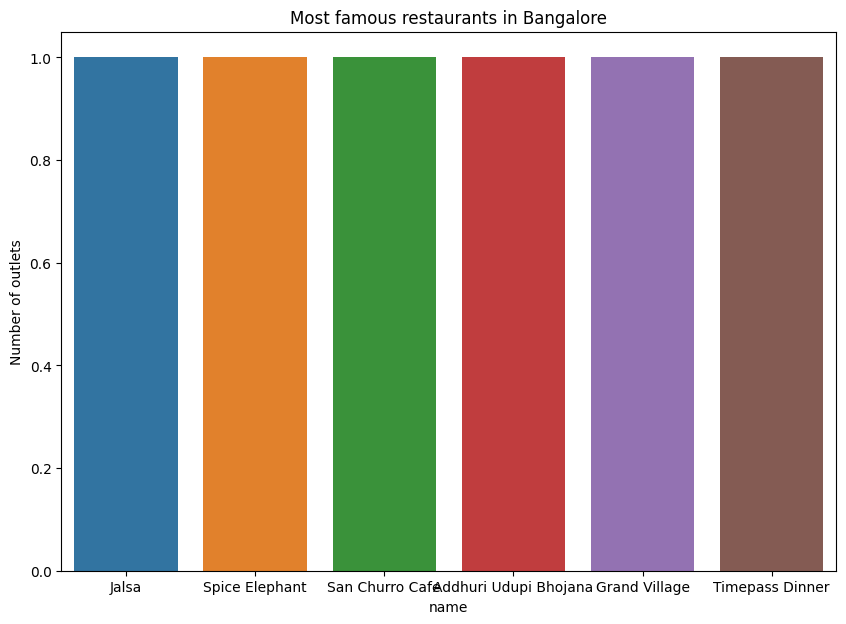

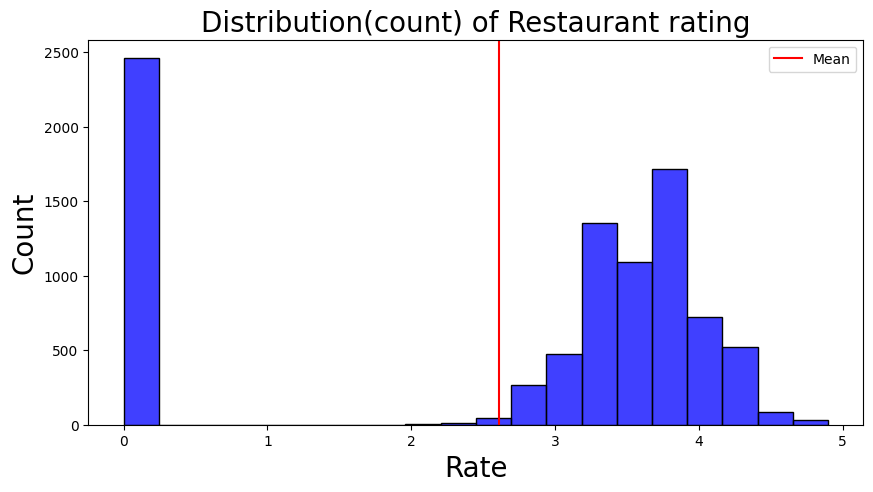

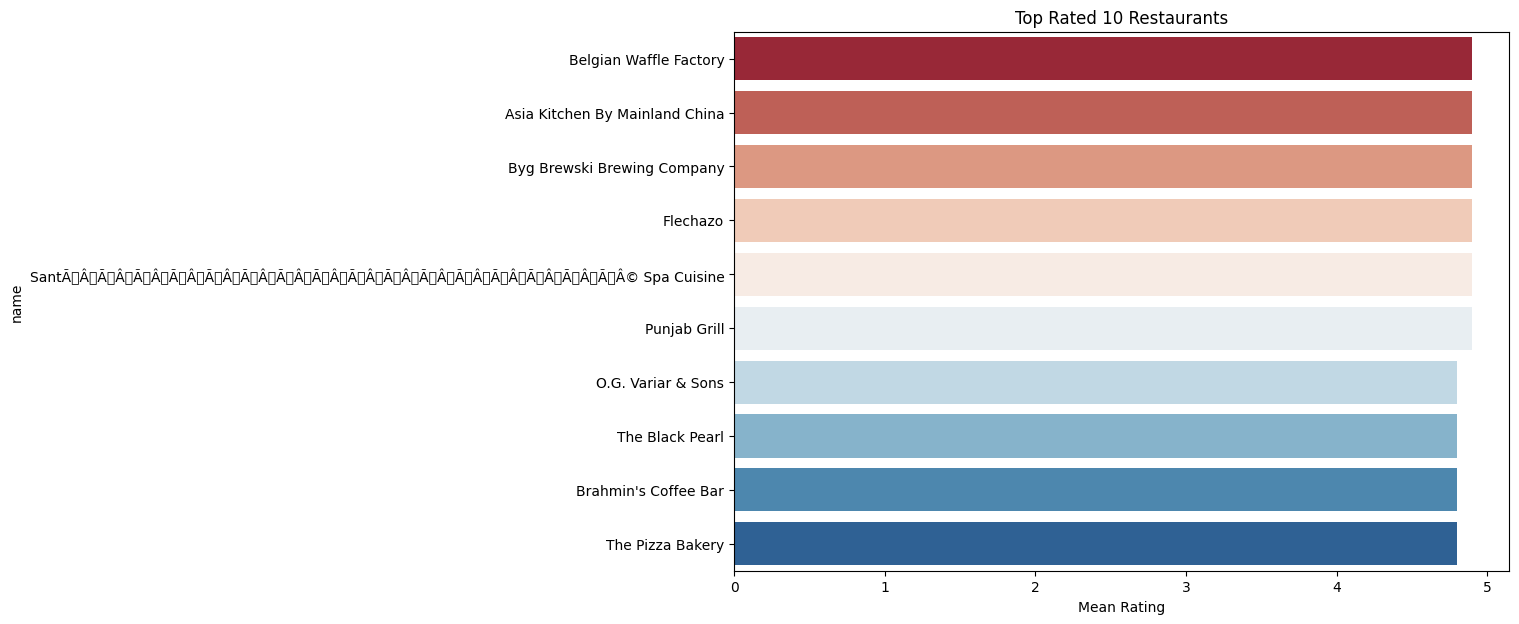

In [15]:
# 1. Most Famous 6 restaurants in Bangalore
plt.figure(figsize=(10,7))
chains = zomato_df['name'].value_counts()[:6]
sns.barplot(x=chains.index, y=chains, palette='tab10')
plt.title("Most famous restaurants in Bangalore")
plt.ylabel("Number of outlets")
plt.show()

# 2. Distribution of Restaurant Rating
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
sns.histplot(zomato_df['Mean Rating'], kde=False, color='b', ax=ax, bins=20)
ax.axvline(zomato_df['Mean Rating'].mean(), 0, 1, color='r', label='Mean')
ax.legend()
ax.set_ylabel('Count', size=20)
ax.set_xlabel('Rate', size=20)
ax.set_title('Distribution(count) of Restaurant rating', size=20)
plt.show()

# 3. Top 10 Rated Restaurants
df_rating = zomato_df.sort_values(by='Mean Rating', ascending=False).head(10)
plt.figure(figsize=(10,7))
sns.barplot(data=df_rating, x='Mean Rating', y='name', palette='RdBu')
plt.title('Top Rated 10 Restaurants')
plt.show()

In [16]:
# Prepare index
df_percent = zomato_df.copy()
df_percent.set_index('name', inplace=True)
indices = pd.Series(df_percent.index)

# Creating tf-idf matrix
tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=0.0, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_percent['reviews_list'].fillna(''))

# Calculating Cosine Similarity
cosine_similarities = linear_kernel(tfidf_matrix, tfidf_matrix)
print("TF-IDF Matrix and Cosine Similarities generated successfully.")

TF-IDF Matrix and Cosine Similarities generated successfully.


In [17]:
def recommend(name, cosine_similarities=cosine_similarities):
    recommend_restaurant = []
    
    if name not in indices.values:
        return "Restaurant not found."

    idx = indices[indices == name].index[0]
    score_series = pd.Series(cosine_similarities[idx]).sort_values(ascending=False)
    top_indexes = list(score_series.iloc[1:min(31, len(score_series))].index)
    
    for each in top_indexes:
        recommend_restaurant.append(list(df_percent.index)[each])
    
    df_new = pd.DataFrame(columns=['cuisines', 'Mean Rating', 'cost'])
    
    for each in recommend_restaurant:
        selected_data = df_percent[['cuisines', 'Mean Rating', 'cost']][df_percent.index == each]
        if not selected_data.empty:
            df_new = pd.concat([df_new, selected_data.sample(n=1)])
    
    df_new = df_new.drop_duplicates(subset=['cuisines', 'Mean Rating', 'cost'], keep=False)
    df_new = df_new.sort_values(by='Mean Rating', ascending=False).head(10)
    
    print(f"TOP 10 RESTAURANTS LIKE {name} WITH SIMILAR REVIEWS: \n")
    return df_new

# Testing the recommendations exactly as requested in the project manual
display(recommend('Red Chilliez'))
display(recommend('Cinnamon'))
display(recommend('Spice Up'))
display(recommend('Desi Doze'))

TOP 10 RESTAURANTS LIKE Red Chilliez WITH SIMILAR REVIEWS: 



,cuisines,Mean Rating,cost
Yo! Chow,"Chinese, Momos",4.4,800.0
Mystique Palate,"Chinese, Fast Food",4.1,300.0
Eggzotic,"North Indian, Chinese, Biryani, Fast Food",4.0,500.0
3 Spice,"North Indian, Chinese",3.9,450.0
Hakka Chinese Restaurant,"Chinese, Thai",3.9,600.0
Pallavi Restaurant,"Biryani, Chinese, Andhra",3.8,500.0
Lion King,"Chinese, Momos",3.8,250.0
Raichur Biryani House,"Biryani, North Indian, Chinese",3.8,400.0
Spice Up,Chinese,3.8,600.0
Magix's Parattha Roll,"Fast Food, North Indian, Chinese, Mughlai, Rolls",3.7,400.0


TOP 10 RESTAURANTS LIKE Cinnamon WITH SIMILAR REVIEWS: 



,cuisines,Mean Rating,cost
Insomniac's Delight,"Fast Food, North Indian",4.0,300.0
Eggzotic,"North Indian, Chinese, Biryani, Fast Food",4.0,500.0
Al Sadique,"North Indian, Mughlai, Chinese, Rolls",3.9,450.0
Mug N Bean,"Cafe, Continental, Italian, Burger",3.9,400.0
Raichur Biryani House,"Biryani, North Indian, Chinese",3.8,400.0
Hunger Hitman,"North Indian, Chinese",3.8,300.0
Hotel Manu Residency,"Andhra, North Indian, Chinese, Biryani",3.8,550.0
Desi Doze,"North Indian, Fast Food",3.8,400.0
Pallavi Restaurant,"Biryani, Chinese, Andhra",3.8,500.0
B.M.W - Bhookh Mitaane Wala,"North Indian, South Indian, Chinese",3.7,500.0


TOP 10 RESTAURANTS LIKE Spice Up WITH SIMILAR REVIEWS: 



,cuisines,Mean Rating,cost
Eggzotic,"North Indian, Chinese, Biryani, Fast Food",4.0,500.0
Al Sadique,"North Indian, Mughlai, Chinese, Rolls",3.9,450.0
Mug N Bean,"Cafe, Continental, Italian, Burger",3.9,400.0
3 Spice,"North Indian, Chinese",3.9,450.0
Pallavi Restaurant,"Biryani, Chinese, Andhra",3.8,500.0
Hotel Manu Residency,"Andhra, North Indian, Chinese, Biryani",3.8,550.0
Raichur Biryani House,"Biryani, North Indian, Chinese",3.8,400.0
Hunger Hitman,"North Indian, Chinese",3.8,300.0
Dhaba Express,"Biryani, Fast Food, North Indian, Chinese",3.7,400.0
B.M.W - Bhookh Mitaane Wala,"North Indian, South Indian, Chinese",3.7,500.0


TOP 10 RESTAURANTS LIKE Desi Doze WITH SIMILAR REVIEWS: 



,cuisines,Mean Rating,cost
Insomniac's Delight,"Fast Food, North Indian",4.0,300.0
Eggzotic,"North Indian, Chinese, Biryani, Fast Food",4.0,500.0
Mug N Bean,"Cafe, Continental, Italian, Burger",3.9,400.0
Al Sadique,"North Indian, Mughlai, Chinese, Rolls",3.9,450.0
Hotel Manu Residency,"Andhra, North Indian, Chinese, Biryani",3.8,550.0
Hunger Hitman,"North Indian, Chinese",3.8,300.0
Pallavi Restaurant,"Biryani, Chinese, Andhra",3.8,500.0
Dhaba Express,"Biryani, Fast Food, North Indian, Chinese",3.7,400.0
B.M.W - Bhookh Mitaane Wala,"North Indian, South Indian, Chinese",3.7,500.0
Desi Urbane,"North Indian, Chinese, Biryani",3.6,450.0


In [18]:
# Exporting the cleaned dataframe and the trained model for the web application
zomato_df.to_csv("restaurant1.csv", index=False)

with open("restaurant.pkl", "wb") as f:
    pickle.dump(cosine_similarities, f)
    
print("Files exported successfully!")

Files exported successfully!
